In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits


from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask, get_pupil_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.lib.make_mask import make_mask

2026-05-18 17:48:48,574 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:48,732 [INFO]: [specula]: Default device is GPU number 0
2026-05-18 17:48:49,167 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:49,167 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:49,169 [INFO]: [specula]: Default device is GPU number 0
2026-05-18 17:48:49,169 [INFO]: [specula]: Default device is GPU number 0
2026-05-18 17:48:49,178 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:49,178 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:49,178 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-18 17:48:49,180 [INFO]: [specula]: Default device is CPU
2026-05-18 17:48:49,180 [INFO]: [specula]: Default device is CPU
2026-05-18 17:48:49,180 [INFO]: [specula]: Default device is CPU


In [ ]:
def analyse_tn(tn:str, show:bool=True, step:int=1, return_SNR:bool=False, sn:bool=False):

    phs = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/'+tn+'/atmo_pc_phs.fits')
    slopes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/'+tn+'/pc_slopes.fits')

    if return_SNR:
        kl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')

        mask = np.sum(abs(phs[:,0,:,:])>0,axis=0).astype(bool)
        phases = np.zeros([np.sum(mask),4000])
        for j in range(4000):
            phi = phs[j,1,:,:]
            phi -= np.mean(phi)
            phases[:,j] = phi[mask]
        modes = kl @ phases

        modes_RMS = np.sqrt(np.mean(modes**2,axis=1))
        # tilts = modes[0]

        # amp = 200
        # pp = np.ones(4000)*amp
        # pp[1::2] *= -1
        # tilts -= pp

        # SNR = amp/abs(tilts)

    if show:
        idx = 207
        plt.figure()
        plt.imshow(np.ma.masked_array(phs[idx,1,:,:],mask=~(abs(phs[idx,0,:,:])>0).astype(bool)),origin='lower',cmap='turbo')
        plt.colorbar()
    
    push = slopes[::2]
    pull = slopes[1::2]

    L = int(4000/step)
    screen_corr = np.zeros(L)

    for j in range(L-step):
        A = phs[j,1,:,:].flatten()
        B = phs[j+step,1,:,:].flatten()
        A -= np.mean(A)
        B -= np.mean(B)
        cov = np.dot(A,B.T)
        norm = np.sqrt(np.sum(A**2)) * np.sqrt(np.sum(B**2))
        screen_corr[j] = np.abs(cov/norm)

    dslopes = (push[::step]-pull[::step])/2

    avg_corr = np.mean(screen_corr[1:])

    if show:
        plt.figure()
        plt.plot(screen_corr)
        plt.title(f'Screen correlation: {avg_corr*1e+2:1.0f}%')
        plt.grid()

    if sn:
        tip_slopes = slopes.copy()
    else:
        tip_slopes = dslopes

    N = tip_slopes.shape[0]
    slopes_err = np.zeros(N)

    # slopes_avg = tip_slopes[0]
    slopes_avg = np.mean(tip_slopes[:j],axis=0)

    for j in range(1,N):
        new_slopes_avg = np.mean(tip_slopes[:j],axis=0)
        slopes_err[j] = np.std(new_slopes_avg-slopes_avg)/np.std(slopes_avg)
        # slopes_avg = new_slopes_avg.copy()

    if show:
        plt.figure()
        plt.loglog(slopes_err[1:],'.')
        plt.grid()
        plt.title('Slope RMS convergence')
        plt.xlabel('# its')
        plt.ylabel(r'$\dfrac{RMS_{new}-RMS_{old}}{RMS_{old}}$')

        plt.figure()
        plt.plot(slopes_avg)
        plt.grid()

    if show and return_SNR:
        total_WFE = np.sqrt(np.sum(modes_RMS**2))
        plt.figure()
        plt.loglog(np.arange(len(modes_RMS))+1,modes_RMS)
        plt.grid()
        plt.xlabel('# KL mode')
        plt.ylabel('amp [nm]')
        plt.title(f'Modes RMS\n{total_WFE:1.0f}nm')

    if return_SNR:
        return slopes_avg,slopes_err,modes_RMS
    else:
        return slopes_avg,slopes_err

In [3]:
# tn = '20260508_145937' # tip only, 30nm amp
# tn = '20260508_150538' # tip only, 30nm amp
# tn = '20260508_160734' # tip only, 30nm amp, screen A
# tn = '20260508_170617' # tip only, 30nm amp, screen B
# tn = '20260508_171644' # tip only, 30nm amp, screen C
# tn = '20260508_172459' # tip only, 30nm amp, screen D

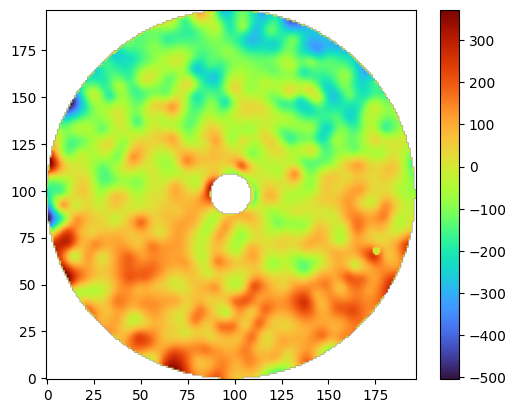

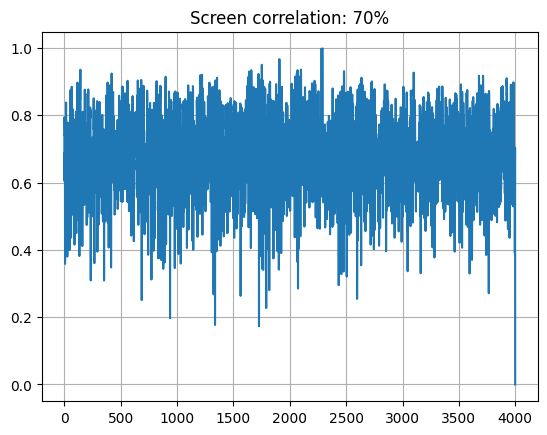

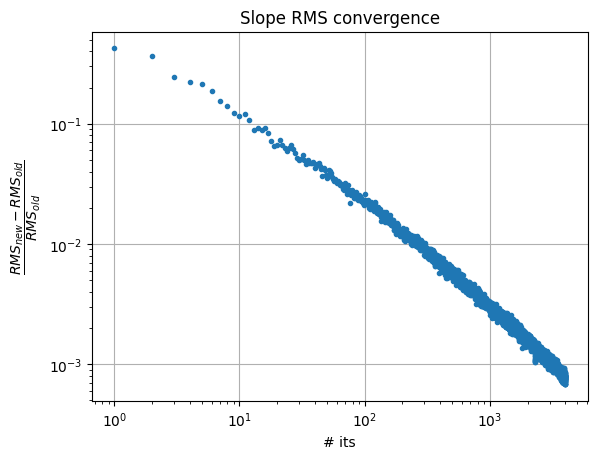

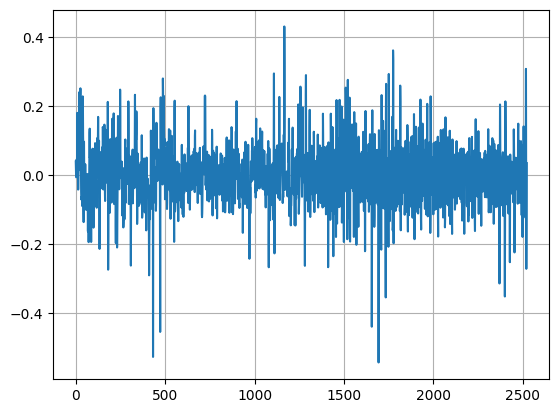

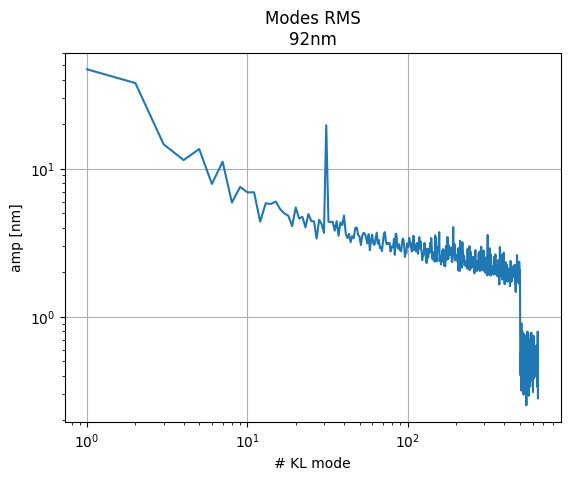

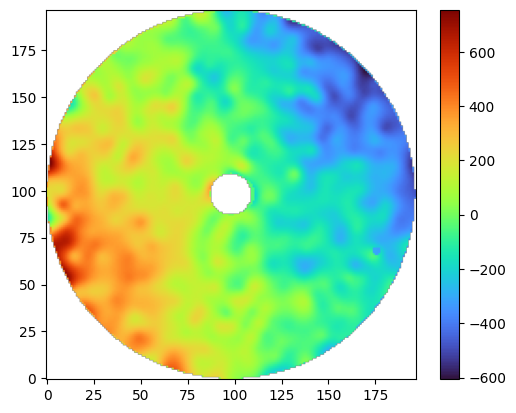

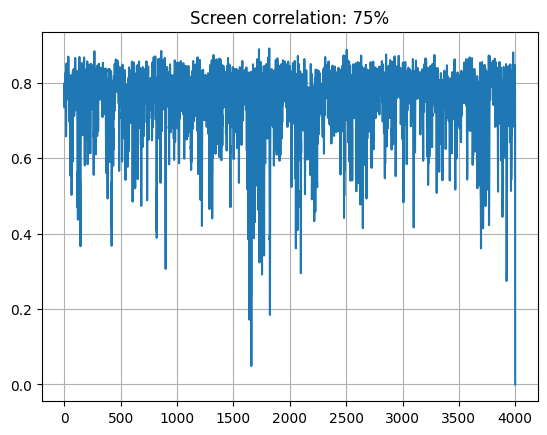

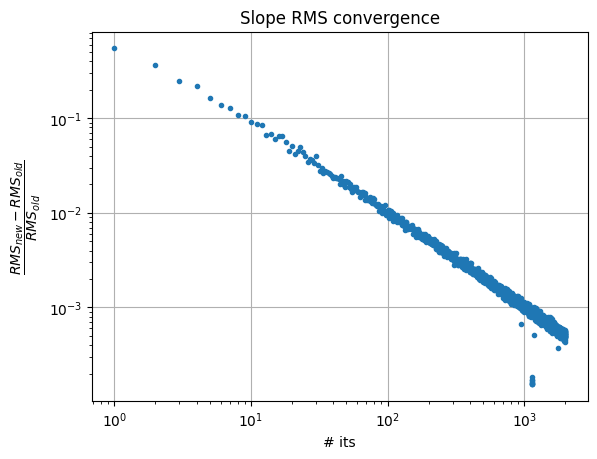

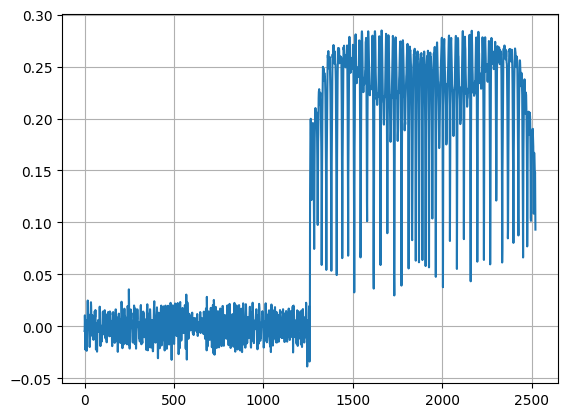

In [4]:
ref_slopes,_ = analyse_tn(tn='20260508_150538',show=False)
pc_slopes,pc_rms,modes_rms = analyse_tn(tn='20260511_092150',return_SNR=True,sn=True)
# pc_slopes_B,pc_rms_B = analyse_tn(tn='20260508_160734')
# pc_slopes_C,pc_rms_C = analyse_tn(tn='20260508_171644')
# pc_slopes_D,pc_rms_D = analyse_tn(tn='20260508_172459')
pc_slopes,pc_rms = analyse_tn(tn='20260511_083817',show=False)
pc_slopes_B,pc_rms_B = analyse_tn(tn='20260511_084128')
# pc_slopes_B,pc_rms_B = analyse_tn(tn='20260511_093305')

In [5]:
# plt.figure()
# plt.loglog(pc_rms,'.',label='no shuffle')
# plt.loglog(pc_rms_shuffle,'.',label='shuffle')
# plt.legend()
# plt.grid()
# plt.ylim([2e-3,1])

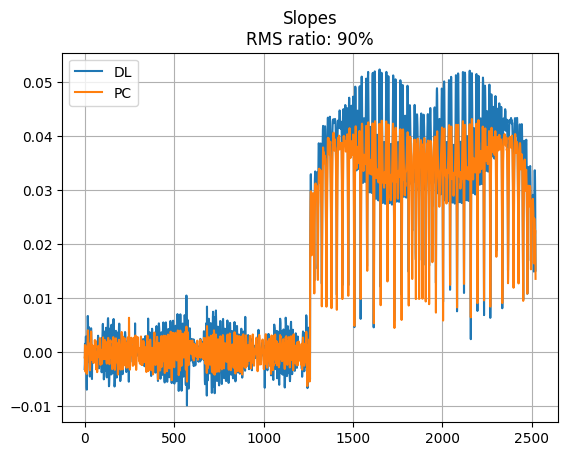

In [6]:
avg_pc_slopes = (pc_slopes*2+pc_slopes_B)/2*30/200

rms_ratio =  np.std(avg_pc_slopes)/np.std(ref_slopes)

plt.figure()
# plt.plot(pc_slopes_shuffle)
plt.plot(ref_slopes,label='DL')
plt.plot(avg_pc_slopes,label='PC')
plt.legend()
plt.title(f'Slopes\nRMS ratio: {rms_ratio*1e+2:1.0f}%')
plt.grid()


In [7]:
# pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pyr_pupdata_40x40.fits')

# plt.figure()
# plt.imshow(pyr_mask)

In [8]:
# soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
# calib_dir = '/raid1/mmenessini/calibration/SOUL/KLv30dx'
# plot_output_data(root_dir=soul_dir,calib_dir=calib_dir,tn='20260506_092825')

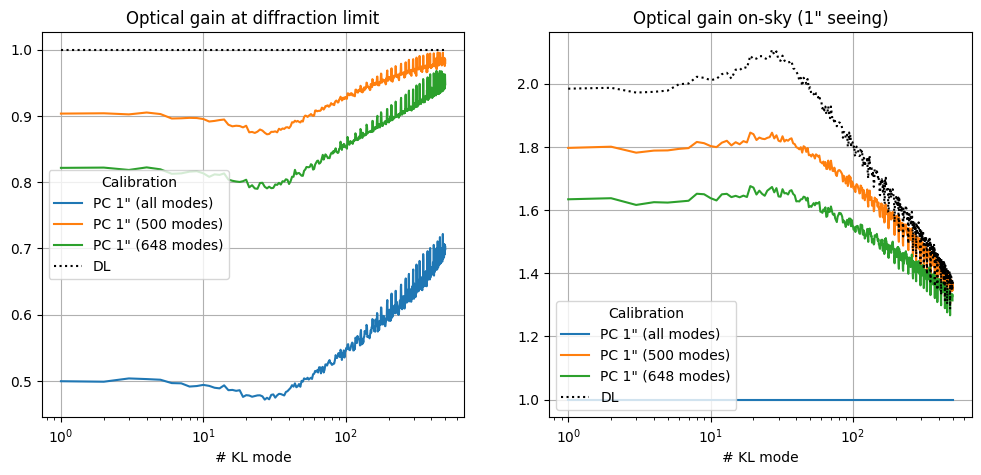

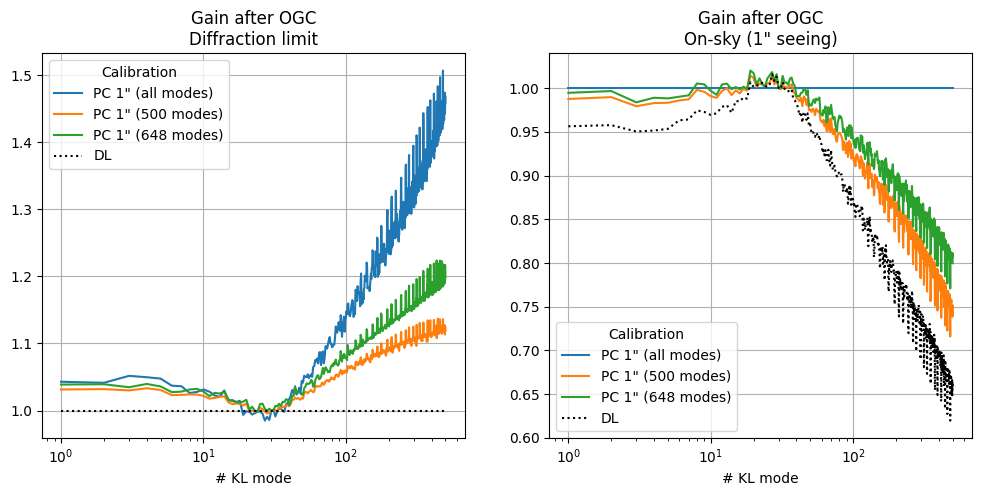

In [9]:
im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')
im_pc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im_pc_nofit = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_nofit_im.fits')
im_pc_zerofit = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_zerofit_im.fits')

N = 500
im = im[:,:N]

norm = np.diag(im.T @ im)
norm_pc = np.diag(im_pc.T @ im_pc)

x = np.arange(N)+1

og_dl = np.diag(im.T @ im)/norm
og = np.diag(im_pc.T @ im)/norm
og_nofit = np.diag(im_pc_nofit.T @ im)/norm
og_zerofit = np.diag(im_pc_zerofit.T @ im)/norm

og_pc_dl = np.diag(im.T @ im_pc)/norm_pc
og_pc = np.diag(im_pc.T @ im_pc)/norm_pc
og_pc_nofit = np.diag(im_pc_nofit.T @ im_pc)/norm_pc
og_pc_zerofit = np.diag(im_pc_zerofit.T @ im_pc)/norm_pc

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og,label='PC 1" (all modes)')
plt.semilogx(x,og_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_dl,':',label='DL',c='k')
plt.title('Optical gain at diffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc,label='PC 1" (all modes)')
plt.semilogx(x,og_pc_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl,':',label='DL',c='k')
plt.title('Optical gain on-sky (1" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

kl_ogc = 29
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og/og[kl_ogc],label='PC 1" (all modes)')
plt.semilogx(x,og_zerofit/og_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit/og_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_dl/og_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nDiffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc/og_pc[kl_ogc],label='PC 1" (all modes)')
plt.semilogx(x,og_pc_zerofit/og_pc_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit/og_pc_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl/og_pc_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nOn-sky (1" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

In [24]:
rec_pc_nofit = np.linalg.pinv(im_pc_nofit)

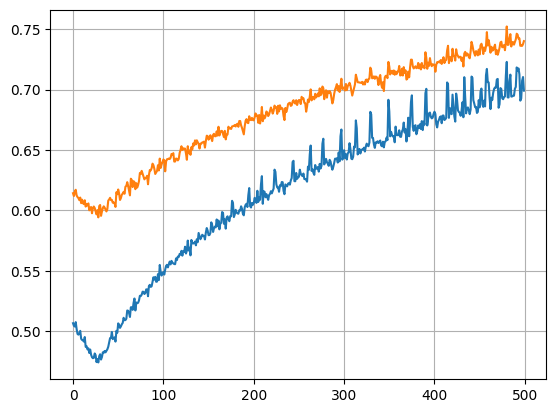

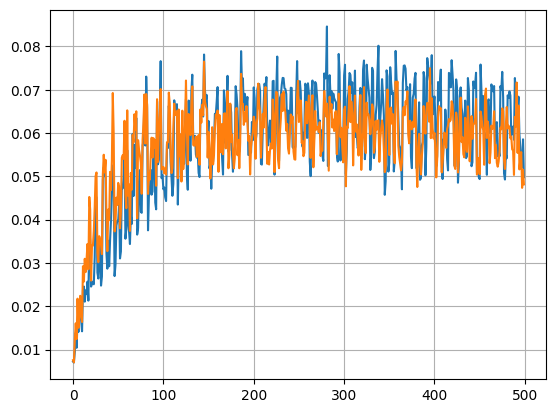

In [25]:

rec = np.linalg.pinv(im)
og2d = rec @ im_pc
og2d_nofit = rec_pc_nofit @ im_pc


isDiag = np.eye(len(og2d)).astype(bool)
ogOffDiag = og2d.copy()
ogOffDiag[isDiag] = np.nan
ogOffDiag_nofit = og2d_nofit.copy()
ogOffDiag_nofit[isDiag] = np.nan

og_offdiag_rms = np.sqrt(np.nansum(ogOffDiag**2,axis=0)) #np.sqrt(np.nanmean(ogOffDiag**2,axis=0))
# og_offdiag_rms2 = np.sqrt(np.nanmean(ogOffDiag[:,:400]**2,axis=1))
og_offdiag_rms_nofit = np.sqrt(np.nansum(ogOffDiag_nofit**2,axis=0))


plt.figure()
plt.plot(np.diag(og2d))
plt.plot(np.diag(og2d_nofit))
plt.grid()
plt.figure()
plt.plot(og_offdiag_rms)
plt.plot(og_offdiag_rms_nofit)
plt.grid()

In [11]:
kl_inv = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
idx = 100

kl = np.linalg.pinv(kl_inv)

In [12]:
phs = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260508_150538/atmo_pc_phs.fits')
mask = np.sum(abs(phs[:,0,:,:])>0,axis=0).astype(bool)

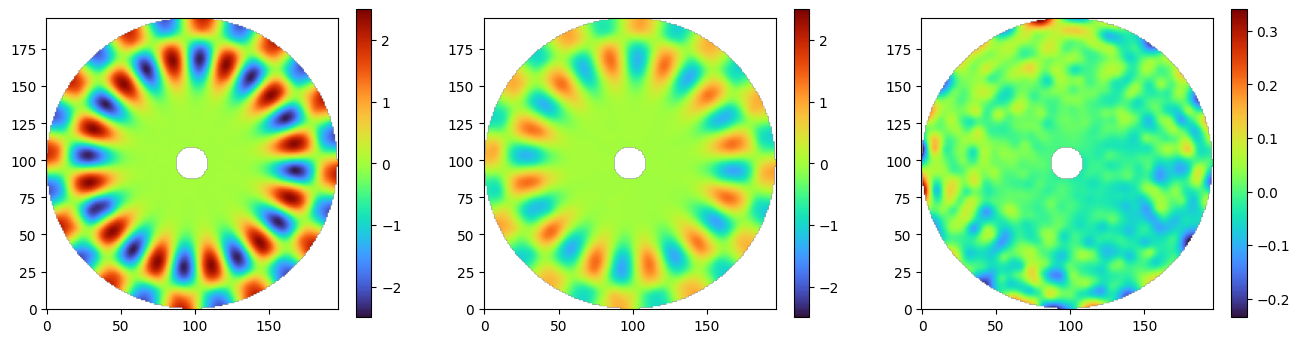

In [22]:
coeffs = rec @ im_pc[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()

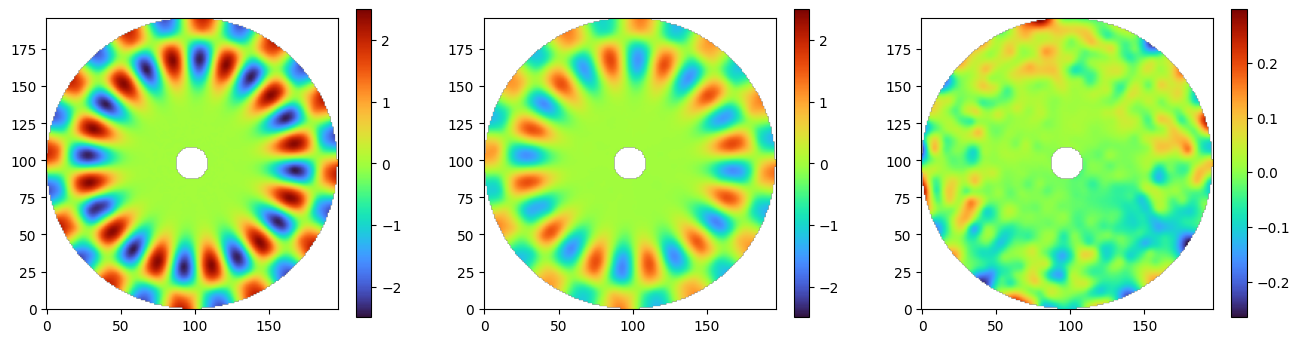

In [26]:
coeffs = rec_pc_nofit @ im_pc[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()

In [14]:
raise ValueError()


ValueError: 

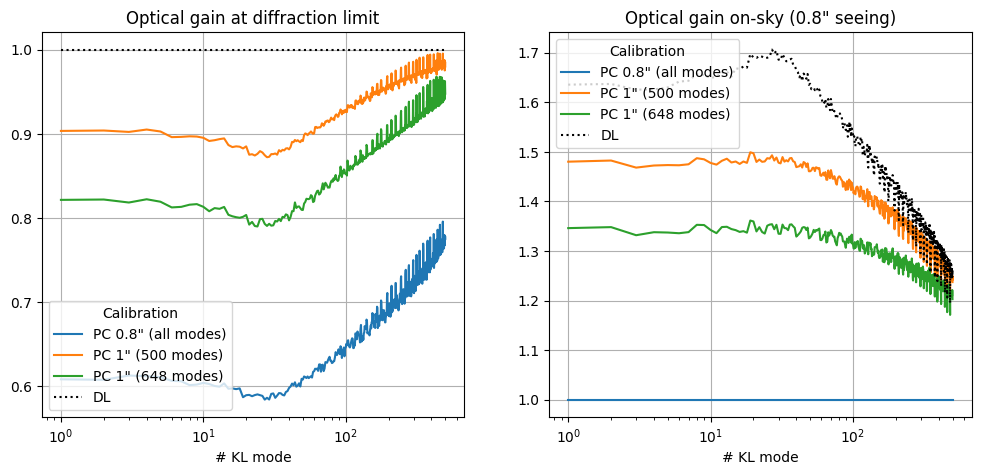

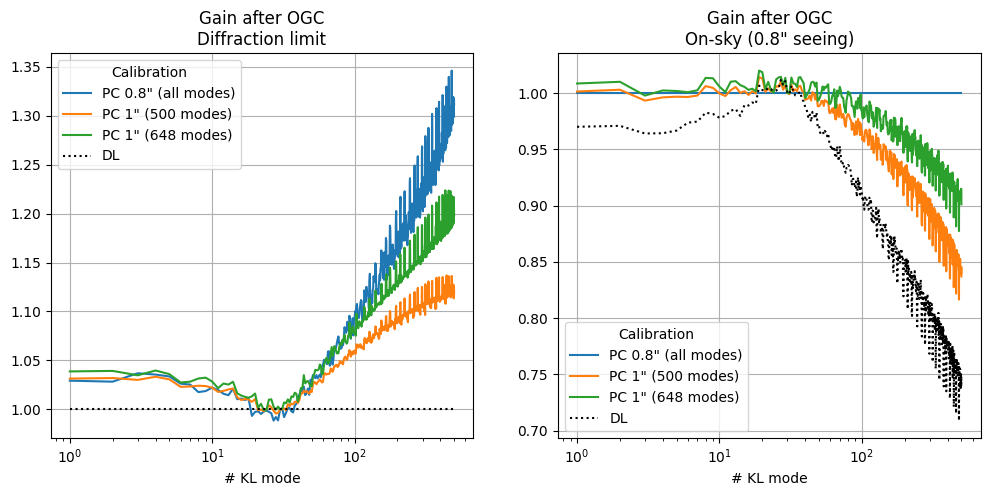

In [ ]:
im_pc08 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.8_c20260506_092825_im.fits')

norm_pc08 = np.diag(im_pc08.T @ im_pc08)

og = np.diag(im_pc08.T @ im)/norm
og_nofit = np.diag(im_pc_nofit.T @ im)/norm
og_zerofit = np.diag(im_pc_zerofit.T @ im)/norm

og_pc_dl = np.diag(im.T @ im_pc08)/norm_pc08
og_pc = np.diag(im_pc08.T @ im_pc08)/norm_pc08
og_pc_nofit = np.diag(im_pc_nofit.T @ im_pc08)/norm_pc08
og_pc_zerofit = np.diag(im_pc_zerofit.T @ im_pc08)/norm_pc08

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og,label='PC 0.8" (all modes)')
plt.semilogx(x,og_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_dl,':',label='DL',c='k')
plt.title('Optical gain at diffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc,label='PC 0.8" (all modes)')
plt.semilogx(x,og_pc_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl,':',label='DL',c='k')
plt.title('Optical gain on-sky (0.8" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og/og[kl_ogc],label='PC 0.8" (all modes)')
plt.semilogx(x,og_zerofit/og_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit/og_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_dl/og_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nDiffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc/og_pc[kl_ogc],label='PC 0.8" (all modes)')
plt.semilogx(x,og_pc_zerofit/og_pc_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit/og_pc_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl/og_pc_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nOn-sky (0.8" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

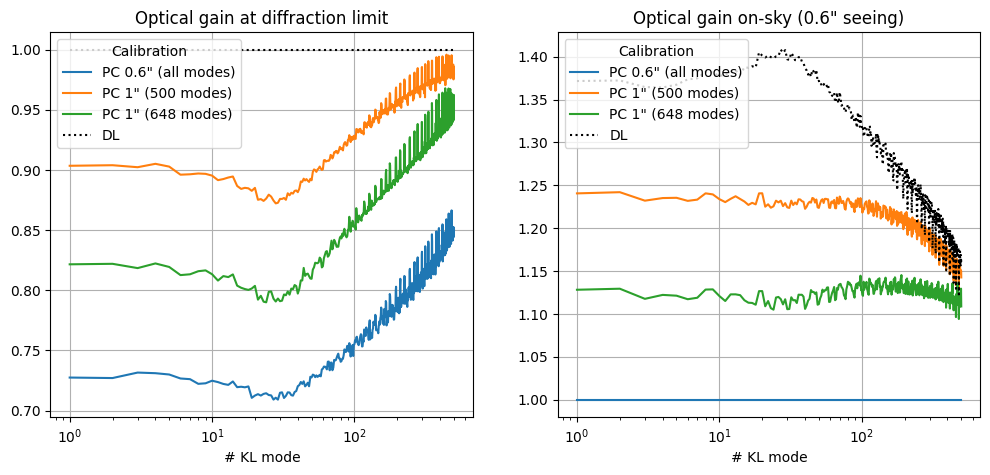

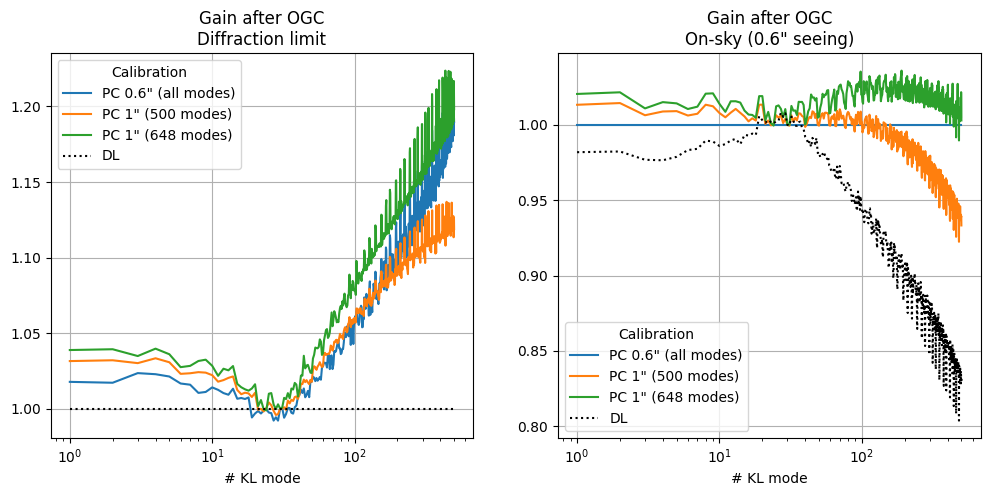

In [ ]:
im_pc06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_im.fits')

norm_pc06 = np.diag(im_pc06.T @ im_pc06)

og = np.diag(im_pc06.T @ im)/norm
og_nofit = np.diag(im_pc_nofit.T @ im)/norm
og_zerofit = np.diag(im_pc_zerofit.T @ im)/norm

og_pc_dl = np.diag(im.T @ im_pc06)/norm_pc06
og_pc = np.diag(im_pc06.T @ im_pc06)/norm_pc06
og_pc_nofit = np.diag(im_pc_nofit.T @ im_pc06)/norm_pc06
og_pc_zerofit = np.diag(im_pc_zerofit.T @ im_pc06)/norm_pc06

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og,label='PC 0.6" (all modes)')
plt.semilogx(x,og_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_dl,':',label='DL',c='k')
plt.title('Optical gain at diffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc,label='PC 0.6" (all modes)')
plt.semilogx(x,og_pc_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl,':',label='DL',c='k')
plt.title('Optical gain on-sky (0.6" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og/og[kl_ogc],label='PC 0.6" (all modes)')
plt.semilogx(x,og_zerofit/og_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit/og_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_dl/og_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nDiffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc/og_pc[kl_ogc],label='PC 0.6" (all modes)')
plt.semilogx(x,og_pc_zerofit/og_pc_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit/og_pc_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl/og_pc_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nOn-sky (0.6" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

Text(0.5, 1.0, 'Mode 4 slopes')

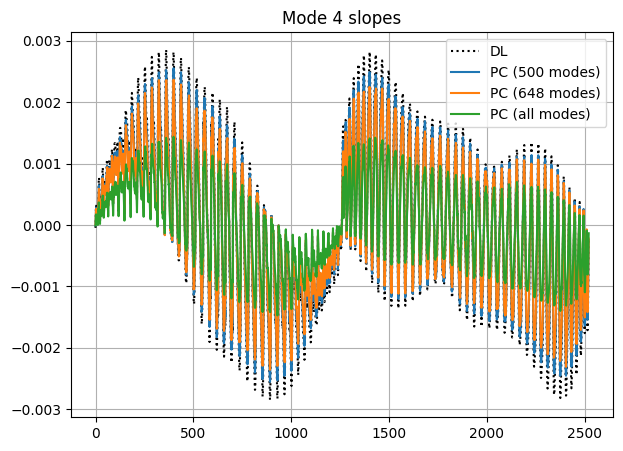

In [ ]:
idx = 4

slopes_dl = im[:,idx]
slopes_pc = im_pc[:,idx]
slopes_pc_zerofit = im_pc_zerofit[:,idx]
slopes_pc_nofit = im_pc_nofit[:,idx]

plt.figure(figsize=(7,5))
plt.plot(slopes_dl,':',label='DL',c='k')
plt.plot(slopes_pc_zerofit,label='PC (500 modes)')
plt.plot(slopes_pc_nofit,label='PC (648 modes)')
plt.plot(slopes_pc,label='PC (all modes)')
plt.grid()
plt.legend()
plt.title(f'Mode {idx} slopes')

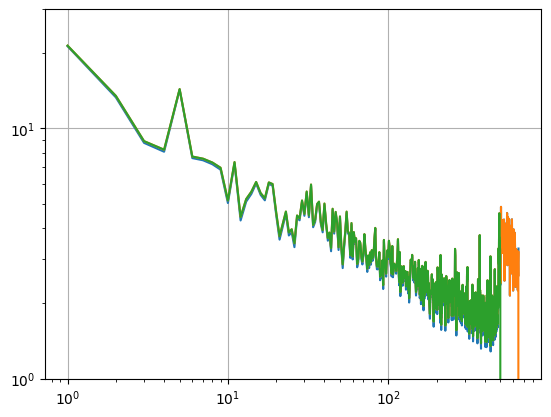

In [ ]:
atmo_modes_nofit = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260511_173304/atmo_res.fits')
atmo_modes_somefit = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260512_101506/atmo_res.fits')
atmo_modes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260511_171947/atmo_res.fits') # 1.0" seeing
# atmo_modes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260512_112945/atmo_res.fits') # 0.6" seeing


atmo_rms = np.sqrt(np.mean(atmo_modes**2,axis=0))#*(1/0.6)**(5/6)
atmo_rms_nofit = np.sqrt(np.mean(atmo_modes_nofit**2,axis=0))
atmo_rms_somefit = np.sqrt(np.mean(atmo_modes_somefit**2,axis=0))

plt.figure()
plt.loglog(np.arange(len(atmo_rms))+1,atmo_rms)
plt.loglog(np.arange(len(atmo_rms_nofit))+1,atmo_rms_somefit)
plt.loglog(np.arange(len(atmo_rms_nofit))+1,atmo_rms_nofit)
plt.ylim([1,30])
plt.grid()